# mCH trinucleotide context (Fig 3B)

Non-CG methylation broken down by trinucleotide context (CAC, CAG, …) across major
cell types, and identification of the cell types with the highest mCA.

_Note: the lambda-spike-in-normalized context heatmaps (a tentative Fig S16) are not
reproduced here — the published values/styling could not be matched, so that analysis
is omitted._

## 📥 Required input files

- `{ENTEX_ROOT}/analysis/mC_context/L2any-donor/*.context.tsv` · _per-cluster trinucleotide-context counts_
- `{ENTEX_ROOT}/clustering/merged/group_meta.tsv` · _cluster → major-type map_
- `{ENTEX_ROOT}/L1color.tsv` · _major-type colors (provided)_
- `{ENTEX_ROOT}/merged_allc/cluster_donor.mcds` · _single-cell mC matrix (for the mCA-region step)_

In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

[repro_guard] active — READ-ONLY (all writes skipped; inline figures still render)


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from glob import glob

import anndata
import scanpy as sc
import scanpy.external as sce
from sklearn.preprocessing import normalize
from sklearn.metrics import pairwise_distances, roc_auc_score

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [3]:
indir = f'{ENTEX_ROOT}/'
file_list = np.sort(glob(f'{indir}analysis/mC_context/L2any-donor/*.context.tsv'))


## Build the trinucleotide-context methylation matrix

Read per-cluster context counts and assemble cluster × context `mc`/`cov` tables (non-`N` contexts), cached to `L2any-donor_context.hdf`.

In [4]:
group_meta = pd.read_csv(f'{indir}clustering/merged/group_meta.tsv', sep='\t', header=0, index_col=0)
# group_meta = group_meta[['L2_any', 'L1', 'count']]
group_meta['L1_annot'] = group_meta['L1_annot'].str.replace(' ','-').str.replace('/','_')
annot2L1 = group_meta[['L1','L1_annot']].set_index('L1_annot')['L1'].to_dict()
L1annot = group_meta[['L1','L1_annot']].set_index('L1')['L1_annot'].to_dict()


In [5]:
mc, cov, cluster = [], [], []
for file in file_list:
    tmp = pd.read_csv(file, index_col=0, header=None, names=['context', 'mc', 'cov'], sep='\t')
    mc.append(tmp['mc'])
    cov.append(tmp['cov'])
    cluster.append(file.split('/')[-1].split('.')[0])
    

In [6]:
mc = pd.concat(mc, axis=1)
mc.columns = cluster
cov = pd.concat(cov, axis=1)
cov.columns = cluster


In [7]:
selc = np.array([('N' not in xx) for xx in mc.index])
mc = mc.loc[selc].T
cov = cov.loc[selc].T


In [8]:
mc.to_hdf('mC_context/L2any-donor_context.hdf', key='mc')
cov.to_hdf('mC_context/L2any-donor_context.hdf', key='cov')


## Fig 3B — mCH by trinucleotide context across major types

Aggregate to major-type level (CH contexts only) and plot mC/C per context, one dot per non-neuronal major type.

In [9]:
selch = np.array([(xx[:2]!='CG') for xx in mc.columns])


In [10]:
groupL1 = pd.Series(mc.index.str.split('-').str[0], index=mc.index)
mc_L1 = mc.groupby(groupL1).sum().loc[:, selch]
cov_L1 = cov.groupby(groupL1).sum().loc[:, selch]


In [11]:
colors = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)['color'].to_dict()


In [12]:
# per-major-type (L1) mCH/CH by context, reshaped long for plotting
tmp = (mc_L1 + 1) / (cov_L1 + 1)
tmp.index.name = 'L1'
tmp = tmp.stack().reset_index()
selc = tmp['L1'].isin(['c10', 'c16', 'c31'])   # exclude neurons (plotted separately)
leg_order = tmp.groupby('context')[0].mean().sort_values().index[::-1]

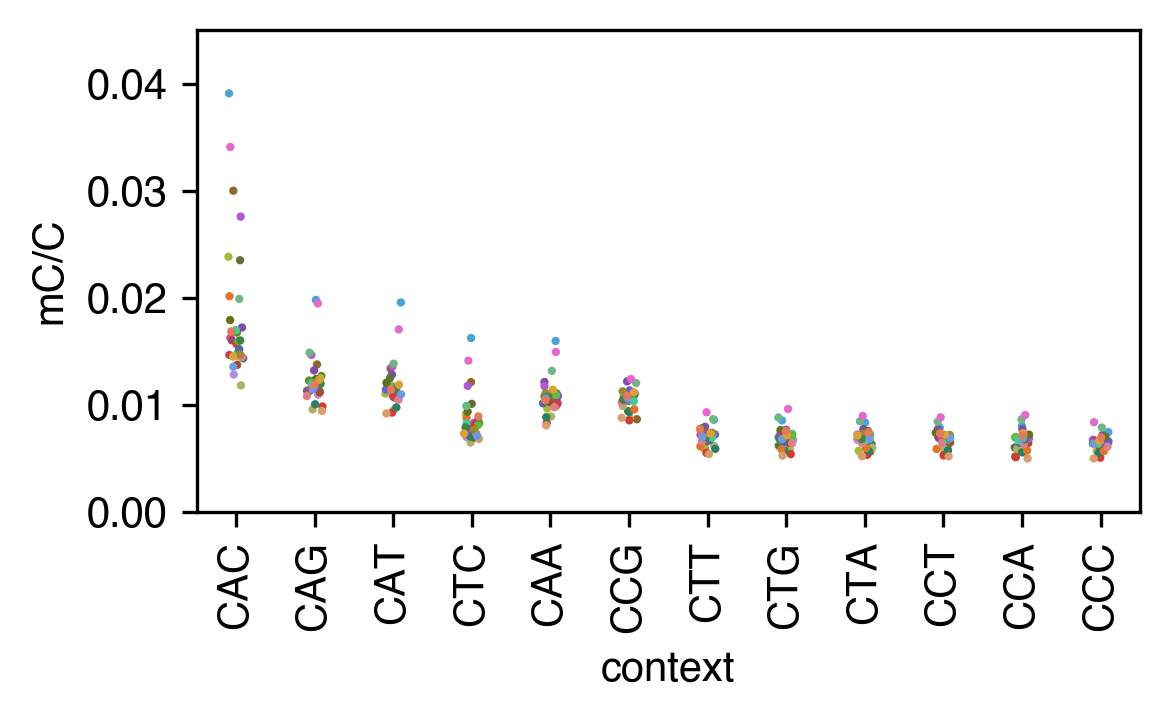

In [13]:
fig, ax = plt.subplots(figsize=(4, 2.5), dpi=300)
sns.stripplot(data=tmp.loc[~selc], x='context', y=0, hue='L1', palette=colors,
              order=leg_order, ax=ax, edgecolor='none', s=2)
ax.set_ylim([0, 0.045])
ax.set_yticks(np.arange(0, 0.05, 0.01))
ax.set_xticks(np.arange(selch.sum()))
ax.set_xticklabels(leg_order, rotation=90)
ax.set_ylabel('mC/C')
ax.get_legend().remove()
fig.tight_layout()
fig.savefig('mCH_distribution/L1_context_scatter.pdf', transparent=True)

## High-mCA cell types → per-bin CA methylation ratio

Identify the L2any clusters with the highest non-CG methylation (top-2 per major type, mCA/CA > 0.025, above the lambda spike-in background) and extract their genome-wide per-1 kb-bin CA methylation ratio. The output **`L2any_mCA_025_top2_rawratio.hdf`** feeds the downstream characterization of high-mCA genomic regions (high-CA vs low-CA domains).

_(Re-run caveat: this step reads the cluster-donor `mcds`, whose cell index differs from `group_meta`; it documents the method but needs the matching index to re-execute from scratch.)_


In [14]:
# the 24 clusters selected above (top-2 highest-mCA per major type)
selc = pd.Index(['c12-c10', 'c13-c5', 'c13-c9', 'c14-c1', 'c14-c2', 'c14-c3', 'c14-c6',
       'c14-c7', 'c21-c8', 'c25-c10', 'c26-c10', 'c31-c0', 'c31-c1', 'c31-c2',
       'c31-c3', 'c31-c4', 'c31-c5', 'c31-c6', 'c31-c7', 'c32-c2', 'c5-c1',
       'c5-c2', 'c5-c5', 'c5-c9'])

In [15]:
from ALLCools.mcds import MCDS

mcds = MCDS.open(f'{indir}merged_allc/cluster_donor.mcds', var_dim='chrom1k')
mcds

<xarray.MCDS> Size: 93GB
Dimensions:        (cell: 940, chrom1k: 3088298, count_type: 2, mc_type: 4)
Coordinates:
  * cell           (cell) <U16 60kB 'c0-c0-PT-1JKYN' ... 'c9-c9-STL003'
  * chrom1k        (chrom1k) <U12 148MB 'chr1_0' 'chr1_1' ... 'chrY_57227'
    chrom1k_chrom  (chrom1k) <U5 62MB ...
    chrom1k_end    (chrom1k) int64 25MB ...
    chrom1k_start  (chrom1k) int64 25MB ...
  * count_type     (count_type) <U3 24B 'mc' 'cov'
  * mc_type        (mc_type) <U3 48B 'CAN' 'CCN' 'CGN' 'CTN'
Data variables:
    chrom1k_da     (cell, chrom1k, mc_type, count_type) uint32 93GB dask.array<chunksize=(1, 386038, 1, 1), meta=np.ndarray>
Attributes:
    obs_dim:  cell
    var_dim:  chrom1k

In [16]:
mcds = mcds.assign_coords(L2_any=('cell', group_meta.loc[mcds.get_index('cell'), 'L2_any']))
mcds = mcds.groupby('L2_any').sum()
mcds = MCDS(mcds, obs_dim='L2_any', var_dim='chrom1k')

KeyError: "None of [Index(['c0-c0-PT-1JKYN', 'c0-c0-PT-1K2DA', 'c0-c0-PT-1LGRB', 'c0-c0-PT-1LVAN',\n       'c0-c0-STL003', 'c0-c1-Other', 'c0-c1-PT-1LGRB', 'c0-c1-PT-1LVAN',\n       'c0-c1-STL003', 'c0-c10-Other',\n       ...\n       'c9-c5-PT-1K2DA', 'c9-c5-STL003', 'c9-c6-PT-1K2DA', 'c9-c6-STL003',\n       'c9-c7-PT-1K2DA', 'c9-c7-STL003', 'c9-c8-PT-1K2DA', 'c9-c8-STL003',\n       'c9-c9-PT-1K2DA', 'c9-c9-STL003'],\n      dtype='object', name='cell', length=940)] are in the [index]"

In [17]:
mcds = mcds.sel({'mc_type':'CAN'})

In [18]:
cov = mcds['chrom1k_da'].sel(count_type='cov').mean(dim='L2_any').squeeze().to_pandas()


ValueError: 'L2_any' not found in array dimensions ('cell', 'chrom1k')

In [19]:
mcds = mcds.sel({'L2_any':selc, 'chrom1k':cov.index[cov>100]})

black_list_path = f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz'
mcds = mcds.remove_black_list_region(
    black_list_path=black_list_path, f=0.5
)

exclude_chromosome = ['chrX', 'chrY', 'chrM', 'chrL']
mcds = mcds.remove_chromosome(exclude_chromosome)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [20]:
mc  = mcds.sel({'count_type':'mc'})['chrom1k_da'].to_pandas()
cov = mcds.sel({'count_type':'cov'})['chrom1k_da'].to_pandas()
data = mc / cov

In [21]:
data.to_hdf('mC_context/L2any_mCA_025_top2_rawratio.hdf', key='data')
